In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.DataFrame([[8,8,4],[7,9,5],[6,10,6],[5,12,7]],columns=['a','b','y'])

In [3]:
df

,a,b,y
0,8,8,4
1,7,9,5
2,6,10,6
3,5,12,7


In [4]:
def initialize_parameters(layers_dim):
    np.random.seed(3)
    parameters = {}
    L = len(layers_dim)
    
    for l in range(1, L):
        parameters['W' + str(l)] = np.ones((layers_dim[l], layers_dim[l-1])) * 0.1
        parameters['b' + str(l)] = np.zeros((layers_dim[l], 1))
    
    return parameters


In [5]:
initialize_parameters([2,2,1])

{'W1': array([[0.1, 0.1],
        [0.1, 0.1]]),
 'b1': array([[0.],
        [0.]]),
 'W2': array([[0.1, 0.1]]),
 'b2': array([[0.]])}

In [6]:
def linear_forward(A_prev,W,b):
    Z=np.dot(W,A_prev)+b
    return Z

In [7]:
# Forward Prop
def L_layer_forward(X, parameters):

  A = X
  L = len(parameters) // 2                  # number of layers in the neural network
  
  for l in range(1, L+1):
    A_prev = A 
    Wl = parameters['W' + str(l)]
    bl = parameters['b' + str(l)]
    #print("A"+str(l-1)+": ", A_prev)
    #print("W"+str(l)+": ", Wl)
    #print("b"+str(l)+": ", bl)
    #print("--"*20)

    A = linear_forward(A_prev, Wl, bl)
    #print("A"+str(l)+": ", A)
    #print("**"*20)
          
  return A,A_prev

In [8]:
X=df[['a','b']].values[0].reshape(2,1)
y=df[['y']].values[0][0]

parameters=initialize_parameters([2,2,1])
print(X)
print(y)
parameters

[[8]
 [8]]
4


{'W1': array([[0.1, 0.1],
        [0.1, 0.1]]),
 'b1': array([[0.],
        [0.]]),
 'W2': array([[0.1, 0.1]]),
 'b2': array([[0.]])}

In [9]:
y_hat,A1=L_layer_forward(X,parameters)

In [10]:
y_hat=y_hat[0][0]
print(A1)
y_hat

[[1.6]
 [1.6]]


np.float64(0.32000000000000006)

In [11]:
(y-0.32)**2

np.float64(13.5424)

In [12]:
def update_parameters(parameters, y, y_hat, A1, X):
    learning_rate = 0.001
    error = 2 * (y - y_hat)

    parameters['W2'][0][0] = parameters['W2'][0][0] + learning_rate * error * A1[0][0]
    parameters['W2'][0][1] = parameters['W2'][0][1] + learning_rate * error * A1[1][0]
    parameters['b2'][0][0] = parameters['b2'][0][0] + learning_rate * error

    parameters['W1'][0][0] = parameters['W1'][0][0] + learning_rate * error * parameters['W2'][0][0] * X[0][0]
    parameters['W1'][0][1] = parameters['W1'][0][1] + learning_rate * error * parameters['W2'][0][0] * X[1][0]
    parameters['b1'][0][0] = parameters['b1'][0][0] + learning_rate * error * parameters['W2'][0][0]

    parameters['W1'][1][0] = parameters['W1'][1][0] + learning_rate * error * parameters['W2'][0][1] * X[0][0]
    parameters['W1'][1][1] = parameters['W1'][1][1] + learning_rate * error * parameters['W2'][0][1] * X[1][0]
    parameters['b1'][1][0] = parameters['b1'][1][0] + learning_rate * error * parameters['W2'][0][1]


In [13]:
update_parameters(parameters,y,y_hat,A1,X)

In [14]:
parameters

{'W1': array([[0.10658137, 0.10658137],
        [0.10658137, 0.10658137]]),
 'b1': array([[0.00082267],
        [0.00082267]]),
 'W2': array([[0.111776, 0.111776]]),
 'b2': array([[0.00736]])}

In [15]:
X=df[['a','b']].values[1].reshape(2,1)
y=df[['y']].values[1][0]
 
y_hat,A1=L_layer_forward(X,parameters)
y_hat=y_hat[0][0]
print(A1)
y_hat

[[1.70612461]
 [1.70612461]]


np.float64(0.38876756779532284)

In [16]:
update_parameters(parameters,y,y_hat,A1,X)
parameters

{'W1': array([[0.11481311, 0.11716504],
        [0.11481311, 0.11716504]]),
 'b1': array([[0.00199863],
        [0.00199863]]),
 'W2': array([[0.12751067, 0.12751067]]),
 'b2': array([[0.01658246]])}

In [17]:

X=df[['a','b']].values[2].reshape(2,1)
y=df[['y']].values[2][0]
print(X)
print(y)
y_hat,A1=L_layer_forward(X,parameters)
y_hat=y_hat[0][0]
print(A1)
y_hat
print('--'*20)
update_parameters(parameters,y,y_hat,A1,X)
parameters

[[ 6]
 [10]]
6
[[1.86252765]
 [1.86252765]]
----------------------------------------


{'W1': array([[0.12459806, 0.13347329],
        [0.12459806, 0.13347329]]),
 'b1': array([[0.00362946],
        [0.00362946]]),
 'W2': array([[0.14802989, 0.14802989]]),
 'b2': array([[0.02759933]])}

In [18]:
X=df[['a','b']].values[3].reshape(2,1)
y=df[['y']].values[3][0]
print(X)
print(y)
y_hat,A1=L_layer_forward(X,parameters)
y_hat=y_hat[0][0]
print(A1)
y_hat
print('--'*20)
update_parameters(parameters,y,y_hat,A1,X)
parameters

[[ 5]
 [12]]
7
[[2.22829927]
 [2.22829927]]
----------------------------------------


{'W1': array([[0.13571869, 0.1601628 ],
        [0.13571869, 0.1601628 ]]),
 'b1': array([[0.00585359],
        [0.00585359]]),
 'W2': array([[0.17616302, 0.17616302]]),
 'b2': array([[0.04022471]])}

In [22]:
parameters=initialize_parameters([2,2,1])
epochs=150
for i in range(epochs):
    loss = []
    for j in range(df.shape[0]):
        X = df[['a','b']].values[j].reshape(2,1)
        y = df[['y']].values[j][0]

        y_hat, A1 = L_layer_forward(X, parameters)
        y_hat = y_hat[0][0]

        update_parameters(parameters, y, y_hat, A1, X)
        loss.append((y - y_hat)**2)

    print(f"Epoch {i+1}/{epochs} | Mean Loss: {np.mean(loss):.6f}")

parameters


Epoch 1/150 | Mean Loss: 26.249692
Epoch 2/150 | Mean Loss: 19.196344
Epoch 3/150 | Mean Loss: 9.702532
Epoch 4/150 | Mean Loss: 3.027416
Epoch 5/150 | Mean Loss: 1.059708
Epoch 6/150 | Mean Loss: 0.877134
Epoch 7/150 | Mean Loss: 0.904385
Epoch 8/150 | Mean Loss: 0.909891
Epoch 9/150 | Mean Loss: 0.898420
Epoch 10/150 | Mean Loss: 0.881171
Epoch 11/150 | Mean Loss: 0.862456
Epoch 12/150 | Mean Loss: 0.843633
Epoch 13/150 | Mean Loss: 0.825102
Epoch 14/150 | Mean Loss: 0.806970
Epoch 15/150 | Mean Loss: 0.789255
Epoch 16/150 | Mean Loss: 0.771955
Epoch 17/150 | Mean Loss: 0.755057
Epoch 18/150 | Mean Loss: 0.738548
Epoch 19/150 | Mean Loss: 0.722416
Epoch 20/150 | Mean Loss: 0.706648
Epoch 21/150 | Mean Loss: 0.691233
Epoch 22/150 | Mean Loss: 0.676159
Epoch 23/150 | Mean Loss: 0.661417
Epoch 24/150 | Mean Loss: 0.646997
Epoch 25/150 | Mean Loss: 0.632889
Epoch 26/150 | Mean Loss: 0.619084
Epoch 27/150 | Mean Loss: 0.605575
Epoch 28/150 | Mean Loss: 0.592352
Epoch 29/150 | Mean Loss: 0

{'W1': array([[-0.08256734,  0.58329829],
        [-0.08256734,  0.58329829]]),
 'b1': array([[0.01532703],
        [0.01532703]]),
 'W2': array([[0.52754938, 0.52754938]]),
 'b2': array([[0.08356334]])}

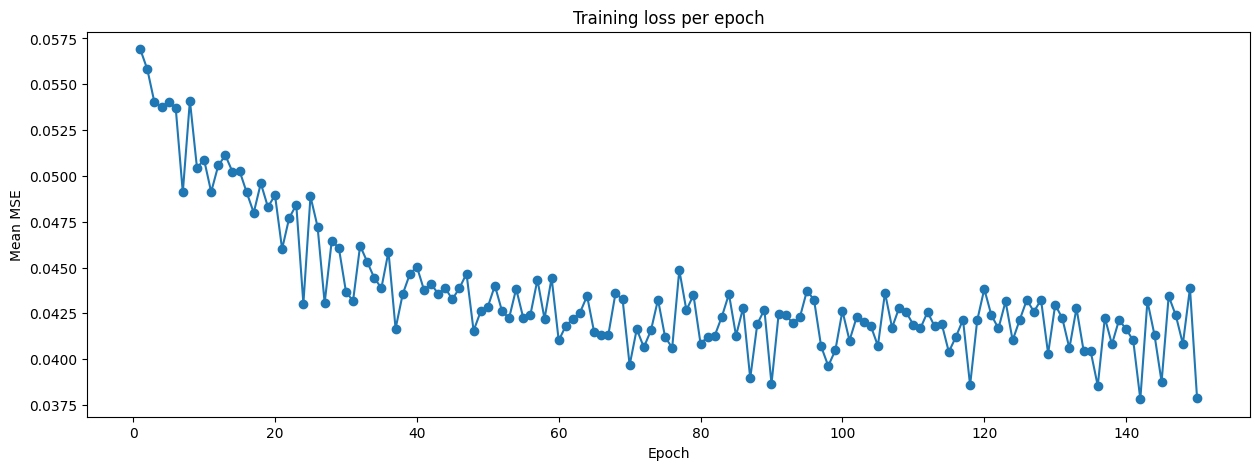

In [23]:
import matplotlib.pyplot as plt

epoch_losses = []
for epoch in range(epochs):
    losses = []
    idx = np.random.permutation(df.shape[0])
    for j in idx:
        X = df[['a','b']].values[j].reshape(2,1)
        y = df[['y']].values[j][0]
        y_hat, A1 = L_layer_forward(X, parameters)
        y_hat = y_hat[0][0]
        update_parameters(parameters, y, y_hat, A1, X)
        losses.append((y - y_hat)**2)
    epoch_loss = np.mean(losses)
    epoch_losses.append(epoch_loss)

plt.figure(figsize=(15,5))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean MSE')
plt.title('Training loss per epoch')
plt.show()


classification

In [24]:
def sigmoid(Z):
    A=1/(1+np.exp(-z))
    return A

In [25]:
def linear_forward_clf(A_prev,W,b):
    Z=np.dot(W,A_prev)+b
    A=sigmoid(Z)
    return A

In [26]:
def update_parameters_clf(parameters, y, y_hat, A1, X):
    lr_output = 0.0001
    lr_hidden = 0.001
    
    # --- Output layer updates ---
    parameters['W2'][0][0] += lr_output * (y - y_hat) * A1[0][0]  # weight from hidden neuron 1
    parameters['W2'][0][1] += lr_output * (y - y_hat) * A1[1][0]  # weight from hidden neuron 2
    parameters['b2'][0][0] += lr_output * (y - y_hat)              # bias for output neuron

    # --- Hidden layer updates ---
    # delta for hidden neurons
    dZ1_0 = (y - y_hat) * parameters['W2'][0][0] * A1[0][0] * (1 - A1[0][0])
    dZ1_1 = (y - y_hat) * parameters['W2'][0][1] * A1[1][0] * (1 - A1[1][0])

    # update W1
    parameters['W1'][0][0] += lr_hidden * dZ1_0 * X[0][0]
    parameters['W1'][0][1] += lr_hidden * dZ1_0 * X[1][0]
    parameters['W1'][1][0] += lr_hidden * dZ1_1 * X[0][0]
    parameters['W1'][1][1] += lr_hidden * dZ1_1 * X[1][0]

    # update b1
    parameters['b1'][0][0] += lr_hidden * dZ1_0
    parameters['b1'][1][0] += lr_hidden * dZ1_1


In [27]:
update_parameters_clf(parameters,y,y_hat,A1,X)

In [28]:
parameters

{'W1': array([[-0.1495095 ,  0.55734859],
        [-0.1495095 ,  0.55734859]]),
 'b1': array([[0.01093221],
        [0.01093221]]),
 'W2': array([[0.54394295, 0.54394295]]),
 'b2': array([[0.08212596]])}

In [29]:
X=df[['a','b']].values[1].reshape(2,1)
y=df[['y']].values[1][0]
 
y_hat,A1=L_layer_forward(X,parameters)
y_hat=y_hat[0][0]
print(A1)
print(y_hat)


update_parameters_clf(parameters,y,y_hat,A1,X)

y_hat_clipped = np.clip(y_hat, 1e-10, 1 - 1e-10)
loss = -y * np.log(y_hat_clipped) - (1 - y) * np.log(1 - y_hat_clipped)
print('loss:', loss)

parameters

[[3.98050308]
 [3.98050308]]
4.412459109977785
loss: -92.10340338830036


{'W1': array([[-0.17606189,  0.5232098 ],
        [-0.17606189,  0.5232098 ]]),
 'b1': array([[0.00713901],
        [0.00713901]]),
 'W2': array([[0.54417682, 0.54417682]]),
 'b2': array([[0.08218471]])}

In [35]:
parameters=initialize_parameters([2,2,1])
epochs=1500
for i in range(epochs):
    loss = []
    for j in range(df.shape[0]):
        X = df[['a','b']].values[j].reshape(2,1)
        y = df[['y']].values[j][0]

        y_hat, A1 = L_layer_forward(X, parameters)
        y_hat = np.clip(y_hat[0][0], 1e-10, 1-1e-10)  # clip to avoid log(0)

        update_parameters_clf(parameters, y, y_hat, A1, X)

        # append loss for this example
        losses.append(-y*np.log(y_hat) - (1-y)*np.log(1-y_hat))

    epoch_loss = np.mean(losses)
    epoch_losses.append(epoch_loss)
    print(f"Epoch {i+1}/{epochs} | Mean Loss: {epoch_loss:.6f}")

parameters


Epoch 1/1500 | Mean Loss: -49.447403
Epoch 2/1500 | Mean Loss: -31.130566
Epoch 3/1500 | Mean Loss: -21.867928
Epoch 4/1500 | Mean Loss: -16.268325
Epoch 5/1500 | Mean Loss: -12.521452
Epoch 6/1500 | Mean Loss: -9.844985
Epoch 7/1500 | Mean Loss: -7.844266
Epoch 8/1500 | Mean Loss: -6.298036
Epoch 9/1500 | Mean Loss: -5.072335
Epoch 10/1500 | Mean Loss: -4.081173
Epoch 11/1500 | Mean Loss: -3.266757
Epoch 12/1500 | Mean Loss: -2.588780
Epoch 13/1500 | Mean Loss: -2.018263
Epoch 14/1500 | Mean Loss: -1.533832
Epoch 15/1500 | Mean Loss: -1.119381
Epoch 16/1500 | Mean Loss: -0.762546
Epoch 17/1500 | Mean Loss: -0.453678
Epoch 18/1500 | Mean Loss: -0.185144
Epoch 19/1500 | Mean Loss: 0.049172
Epoch 20/1500 | Mean Loss: 0.254227
Epoch 21/1500 | Mean Loss: 0.434081
Epoch 22/1500 | Mean Loss: 0.592085
Epoch 23/1500 | Mean Loss: 0.731033
Epoch 24/1500 | Mean Loss: 0.853268
Epoch 25/1500 | Mean Loss: 0.960774
Epoch 26/1500 | Mean Loss: 1.055237
Epoch 27/1500 | Mean Loss: 1.138101
Epoch 28/1500 

{'W1': array([[0.08985571, 0.04129642],
        [0.08985571, 0.04129642]]),
 'b1': array([[0.01381609],
        [0.01381609]]),
 'W2': array([[2.82049113, 2.82049113]]),
 'b2': array([[2.72087234]])}

Epoch 1/1500 | Mean Loss: 4.802998
Epoch 2/1500 | Mean Loss: 5.503834
Epoch 3/1500 | Mean Loss: 5.949351
Epoch 4/1500 | Mean Loss: 6.131897
Epoch 5/1500 | Mean Loss: 6.215439
Epoch 6/1500 | Mean Loss: 6.229044
Epoch 7/1500 | Mean Loss: 6.154190
Epoch 8/1500 | Mean Loss: 6.071996
Epoch 9/1500 | Mean Loss: 5.972574
Epoch 10/1500 | Mean Loss: 5.835254
Epoch 11/1500 | Mean Loss: 5.681517
Epoch 12/1500 | Mean Loss: 5.546792
Epoch 13/1500 | Mean Loss: 5.404382
Epoch 14/1500 | Mean Loss: 5.255259
Epoch 15/1500 | Mean Loss: 5.093389
Epoch 16/1500 | Mean Loss: 4.947702
Epoch 17/1500 | Mean Loss: 4.787125
Epoch 18/1500 | Mean Loss: 4.655308
Epoch 19/1500 | Mean Loss: 4.508987
Epoch 20/1500 | Mean Loss: 4.354306
Epoch 21/1500 | Mean Loss: 4.202740
Epoch 22/1500 | Mean Loss: 4.063110
Epoch 23/1500 | Mean Loss: 3.931910
Epoch 24/1500 | Mean Loss: 3.799932
Epoch 25/1500 | Mean Loss: 3.644372
Epoch 26/1500 | Mean Loss: 3.507684
Epoch 27/1500 | Mean Loss: 3.364651
Epoch 28/1500 | Mean Loss: 3.234570
E

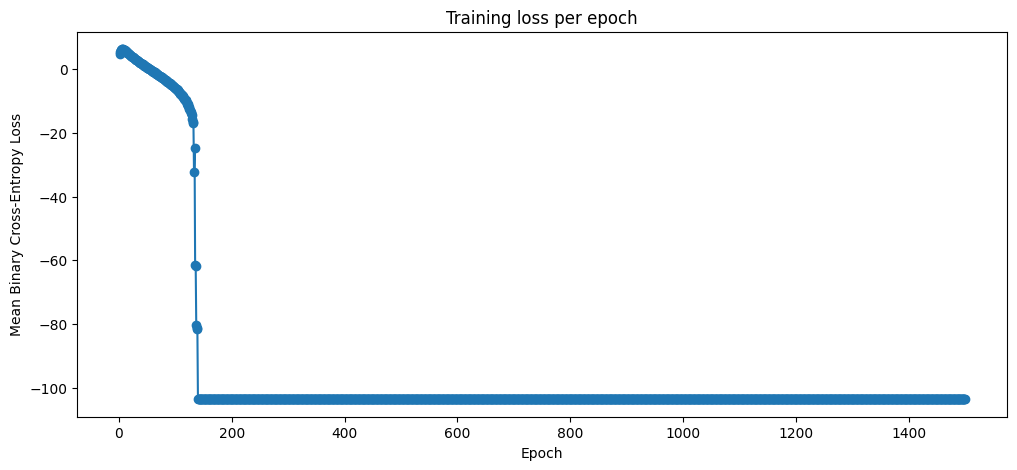

In [36]:
parameters = initialize_parameters([2,2,1])
epochs = 1500

epoch_losses = []

for i in range(epochs):
    losses = []
    idx = np.random.permutation(df.shape[0])
    
    for j in idx:
        X = df[['a','b']].values[j].reshape(2,1)
        y = df[['y']].values[j][0]

        y_hat, A1 = L_layer_forward(X, parameters)
        y_hat = np.clip(y_hat[0][0], 1e-10, 1-1e-10)  # clip to avoid log(0)

        update_parameters_clf(parameters, y, y_hat, A1, X)

        # append loss for this example
        losses.append(-y*np.log(y_hat) - (1-y)*np.log(1-y_hat))

    epoch_loss = np.mean(losses)
    epoch_losses.append(epoch_loss)
    print(f"Epoch {i+1}/{epochs} | Mean Loss: {epoch_loss:.6f}")

# plot loss
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Mean Binary Cross-Entropy Loss')
plt.title('Training loss per epoch')
plt.show()
